# Exploratory Data Analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

###  Business Problem - HR wants to predict the Employee Attrition

#### Load the dataset from CSV file and check first 5 records using head()

In [4]:
# Grabs the notebook's directory instead of relying on __file__
notebook_dir = os.getcwd() 

employee_df = pd.read_csv(notebook_dir+"/docs/HR-Employee-Attrition.csv")
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Analyse the numerical column values using describe method to find count of values, mean, Std Dev, min/max, quartiles

In [5]:
employee_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Missing Value Analysis

In [6]:
employee_df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
# Having a backup of the data frame
backup_df = employee_df.copy()

### Removing Unwanted Columns from the dataset

In [8]:
#Remove unwanted columns from dataset
employee_df.drop(["Over18","EmployeeCount","EmployeeNumber","StandardHours"],axis=1,inplace=True)

In [9]:
employee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

## Target Variable Analysis

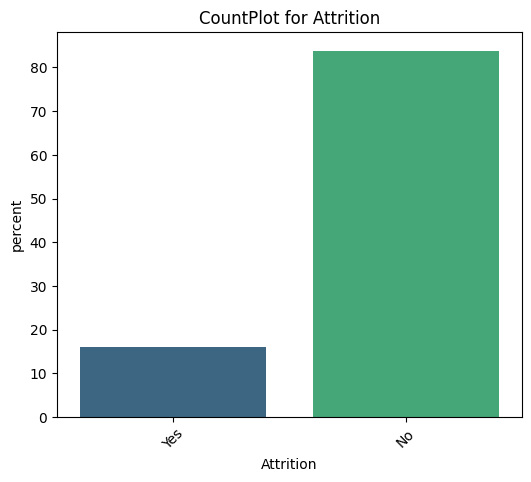

In [10]:
employee_df["Attrition"].value_counts(normalize=True)*100
plt.figure(figsize=(6, 5))
plt.xticks(rotation=45)
plt.title(f"CountPlot for Attrition")
sns.countplot(data=employee_df,x="Attrition",hue="Attrition",palette="viridis",stat="percent",legend="auto")
plt.show();

## Numerical Feature Analysis

In [11]:
#Getting the numerical columns
numeric_cols = employee_df.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


In [59]:
numeric_cols_v1 =  ['Education','EnvironmentSatisfaction',  'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TrainingTimesLastYear',
       'WorkLifeBalance',  'YearsInCurrentRole',
        'YearsWithCurrManager']

In [51]:
box_plot_list = ['Age','MonthlyIncome','YearsAtCompany','DailyRate','MonthlyRate','HourlyRate','DistanceFromHome',
                 'TotalWorkingYears','YearsSinceLastPromotion']

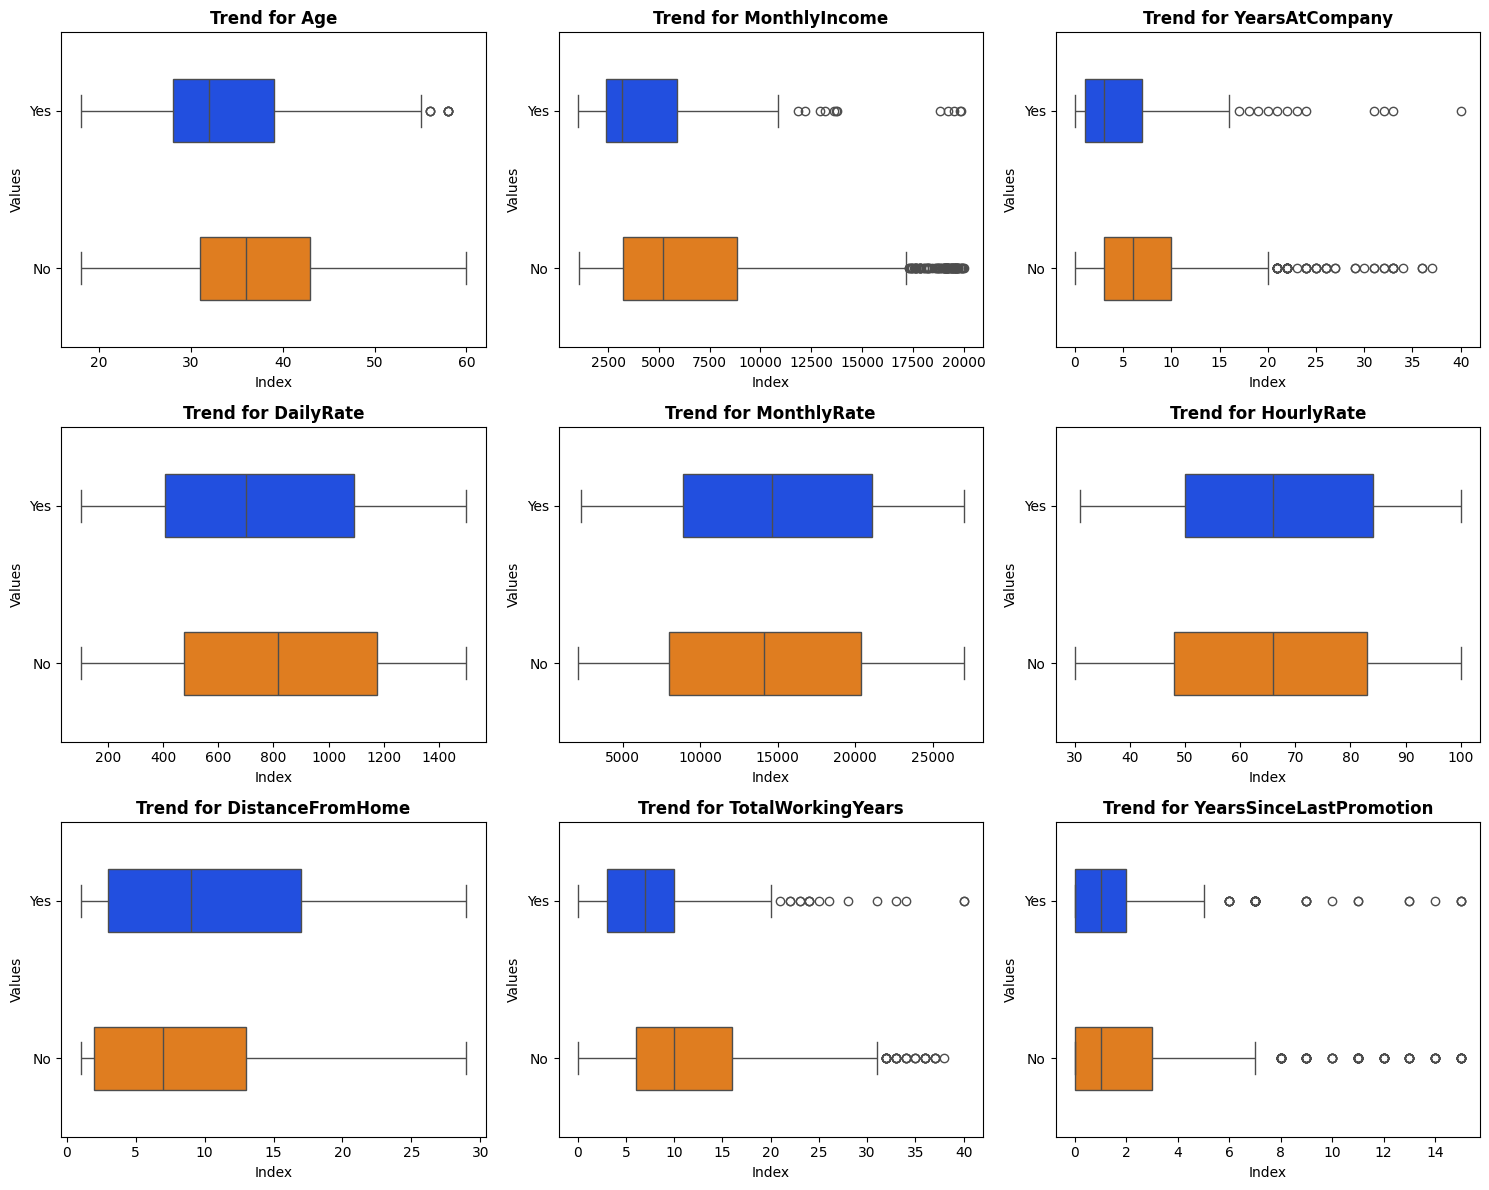

In [58]:
#  Initialize the grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Flatten the axes array for easy 1D iteration
axes_flat = axes.flatten()

#  Loop through columns and axes simultaneously
for index, col_name in enumerate(box_plot_list):
    ax = axes_flat[index]
    
    # Generate the plot on the specific axis
    sns.boxplot(data=employee_df,x=col_name,y="Attrition",hue="Attrition",ax=ax,palette="bright",width=0.4)
   
    # Customize the individual subplot
    ax.set_title(f'Trend for {col_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Index', fontsize=10)
    ax.set_ylabel('Values', fontsize=10)
   
# Hide any unused/empty subplots in the grid
for remaining_index in range(len(box_plot_list), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_index])

#  Optimize spacing and display
plt.tight_layout()
plt.show();

## Insights from Numerical Features ( Age, MonthlyIncome, YearsAtCompany, DailyRate, MonthlyRate, HourlyRate, DistanceFromHome, TotalWorkingYears, YearsSinceLastPromotion)

- The median monthly income for employees who leave  is significantly lower—hovering around $3,000 to $3,500—compared to those who stay , whose median is closer to $5,500. Additionally, the income spread for the attrition group is highly compressed.
- Employees within their first 3 to 5 years of professional life tend to leave the organization.
-  Employees traveling farther are significantly more likely to resign.
- Age Demographics (Age)Insight: The median age of employees leaving is younger (around 32 years old) compared to those staying (around 36 years old).Business Impact: Younger demographics inherently possess higher mobility and lower switching costs, making them a higher-risk group that requires targeted engagement programs.
-  The distribution boxes, medians, and ranges for Daily, Monthly, and Hourly rates are virtually identical between both groups and do not provide any udeful insights for Attrition
- Promotion Stagnation - A lack of recent promotions isn't a standalone differentiator for attrition here; people who stay and people who leave have been promoted at similar intervals.

### Remaining Numerical Columns Analysis

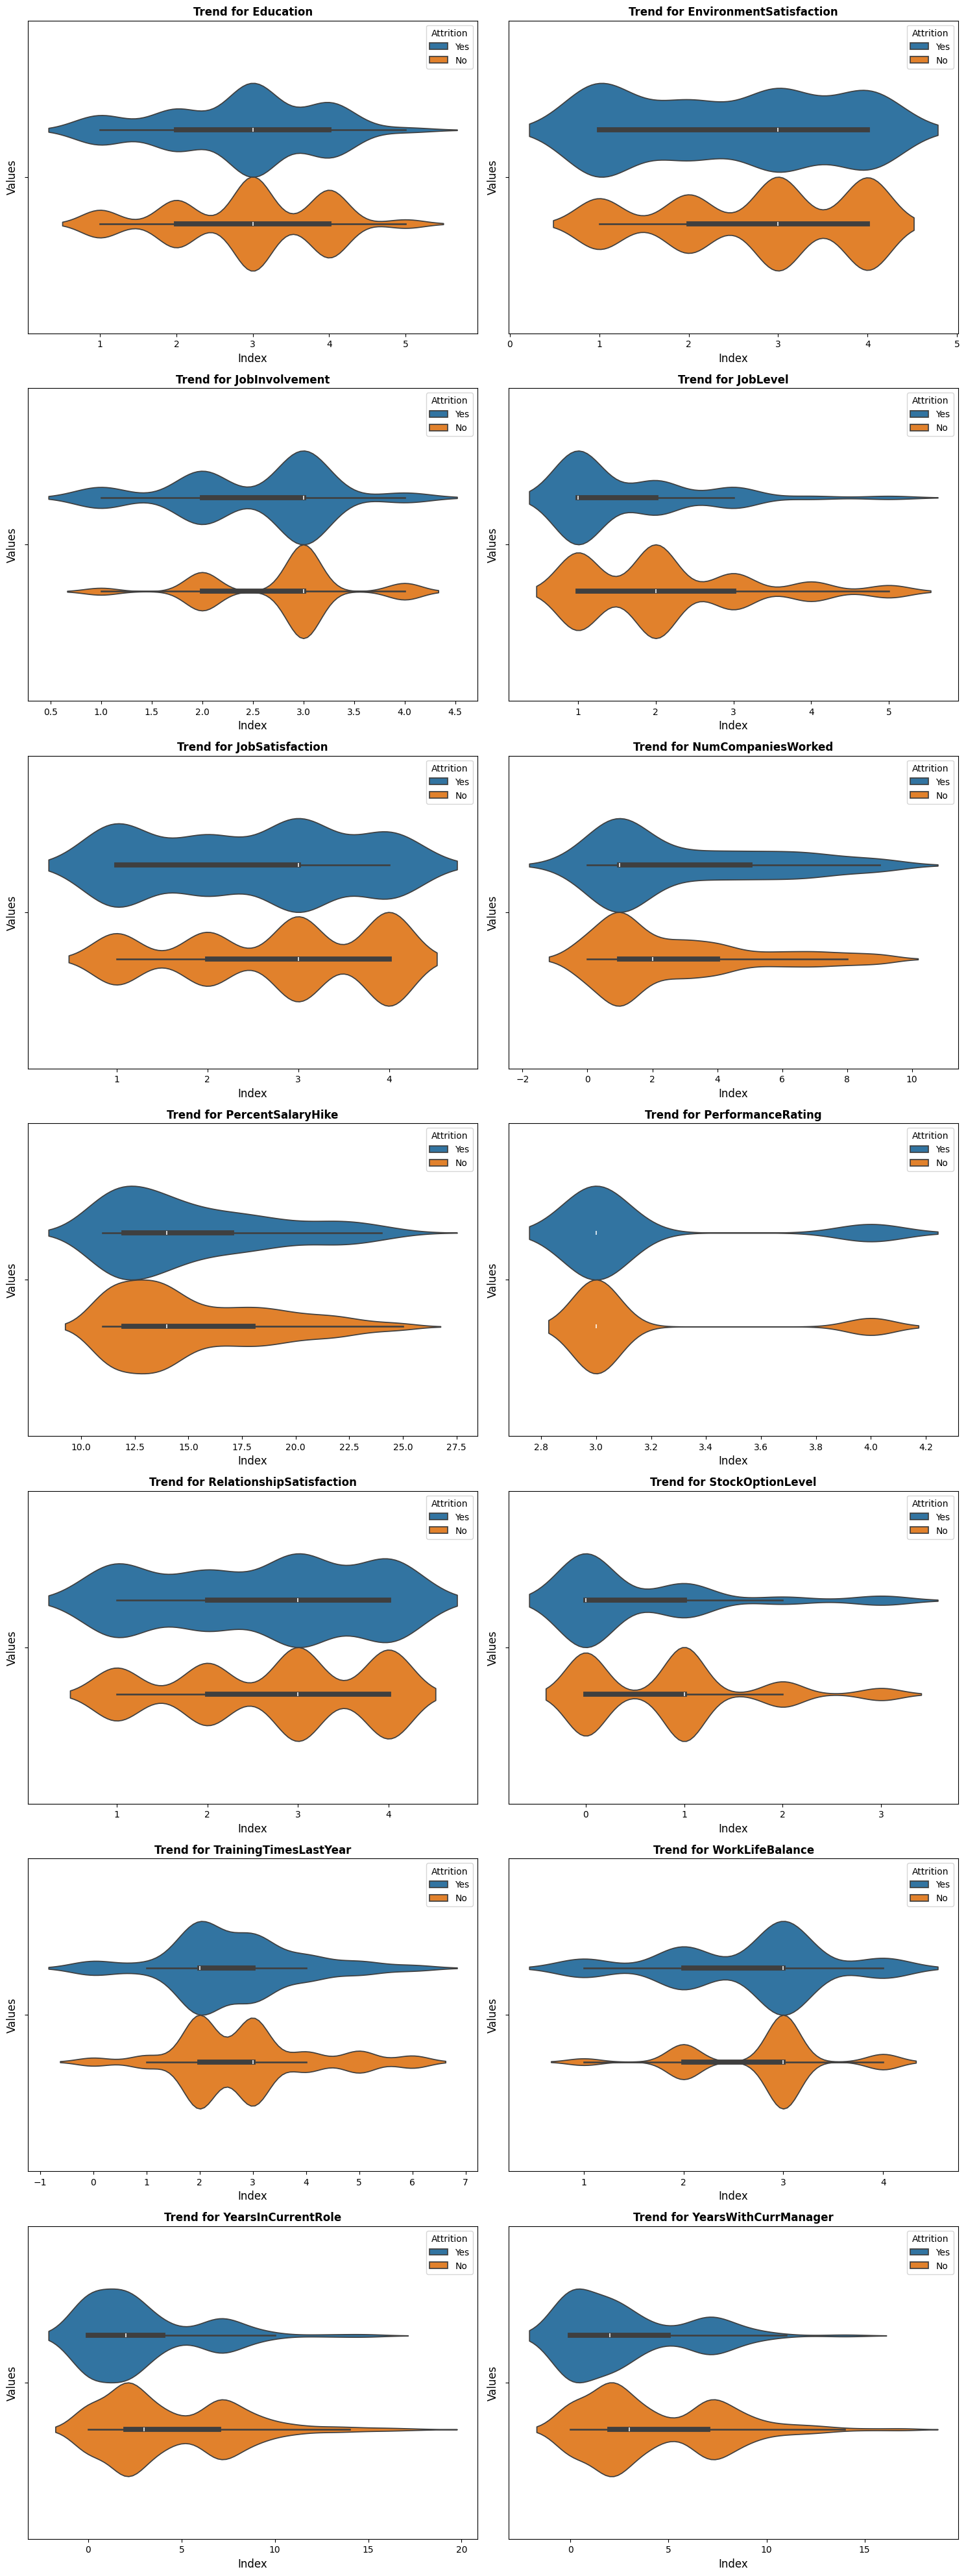

In [ ]:
#  Initialize the grid of subplots
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(15, 45))

# Flatten the axes array for easy 1D iteration
axes_flat = axes.flatten()

#  Loop through columns and axes simultaneously
for index, col_name in enumerate(numeric_cols_v1):
    ax = axes_flat[index]
    
    # Generate the plot on the specific axis
    sns.violinplot(data=employee_df,x=col_name,hue="Attrition", ax=ax,width=0.6)
    sns.color_palette("hls",8)
    # Customize the individual subplot
    ax.set_title(f'Trend for {col_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Index', fontsize=12)
    ax.set_ylabel('Values', fontsize=12)

# Hide any unused/empty subplots in the grid
for remaining_index in range(len(numeric_cols_v1), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_index])

#  Optimize spacing and display
plt.tight_layout()
plt.show();

## Insights from Numerical Features

- Employees with zero stock options leave at a disproportionately high rate, while even a small stock option incentive (Levels 1 and 2) strongly correlates with employees staying.
- Attrition is heavily skewed toward Level 1 (entry-level roles). Senior employees almost never leave.
- Attrition peaks sharply within the first 0 to 2 years in a role or under a specific manager. If an employee survives past the 3-year mark, their likelihood of leaving drops drastically.
- Poor work environments and low day-to-day satisfaction are direct triggers for exit behavior.

- Employees who have worked at less than 2 companies exhibit a higher baseline risk of exiting the organization.
- Employees with poor worklife balance tend to leave the organization.
- Employees who received exactly 2 training sessions show a massive spike in attrition. Employees with 3 or training sessions last year tend to stay.
- Attrition happens independently of performance scores.
- A lower salary hike does not appear to uniquely trigger higher attrition compared to those who stay.
- The distribution across education levels (1 through 5) is completely mirrored between those who leave and those who stay. Educational background is not a reliable predictor of attrition.
-  The waves and peaks line up almost perfectly across both color profiles, meaning interpersonal relationships with peers show no distinct correlation to exit rates.

## Categorical Columns List

In [14]:
categorical_cols = employee_df.select_dtypes(exclude=np.number).columns.tolist()
#Categorical columns without Attrition (Target Variable)
cat_cols_without_attr = categorical_cols.copy()
cat_cols_without_attr.remove("Attrition")
print(cat_cols_without_attr)


['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## Plots for Categorical Columns

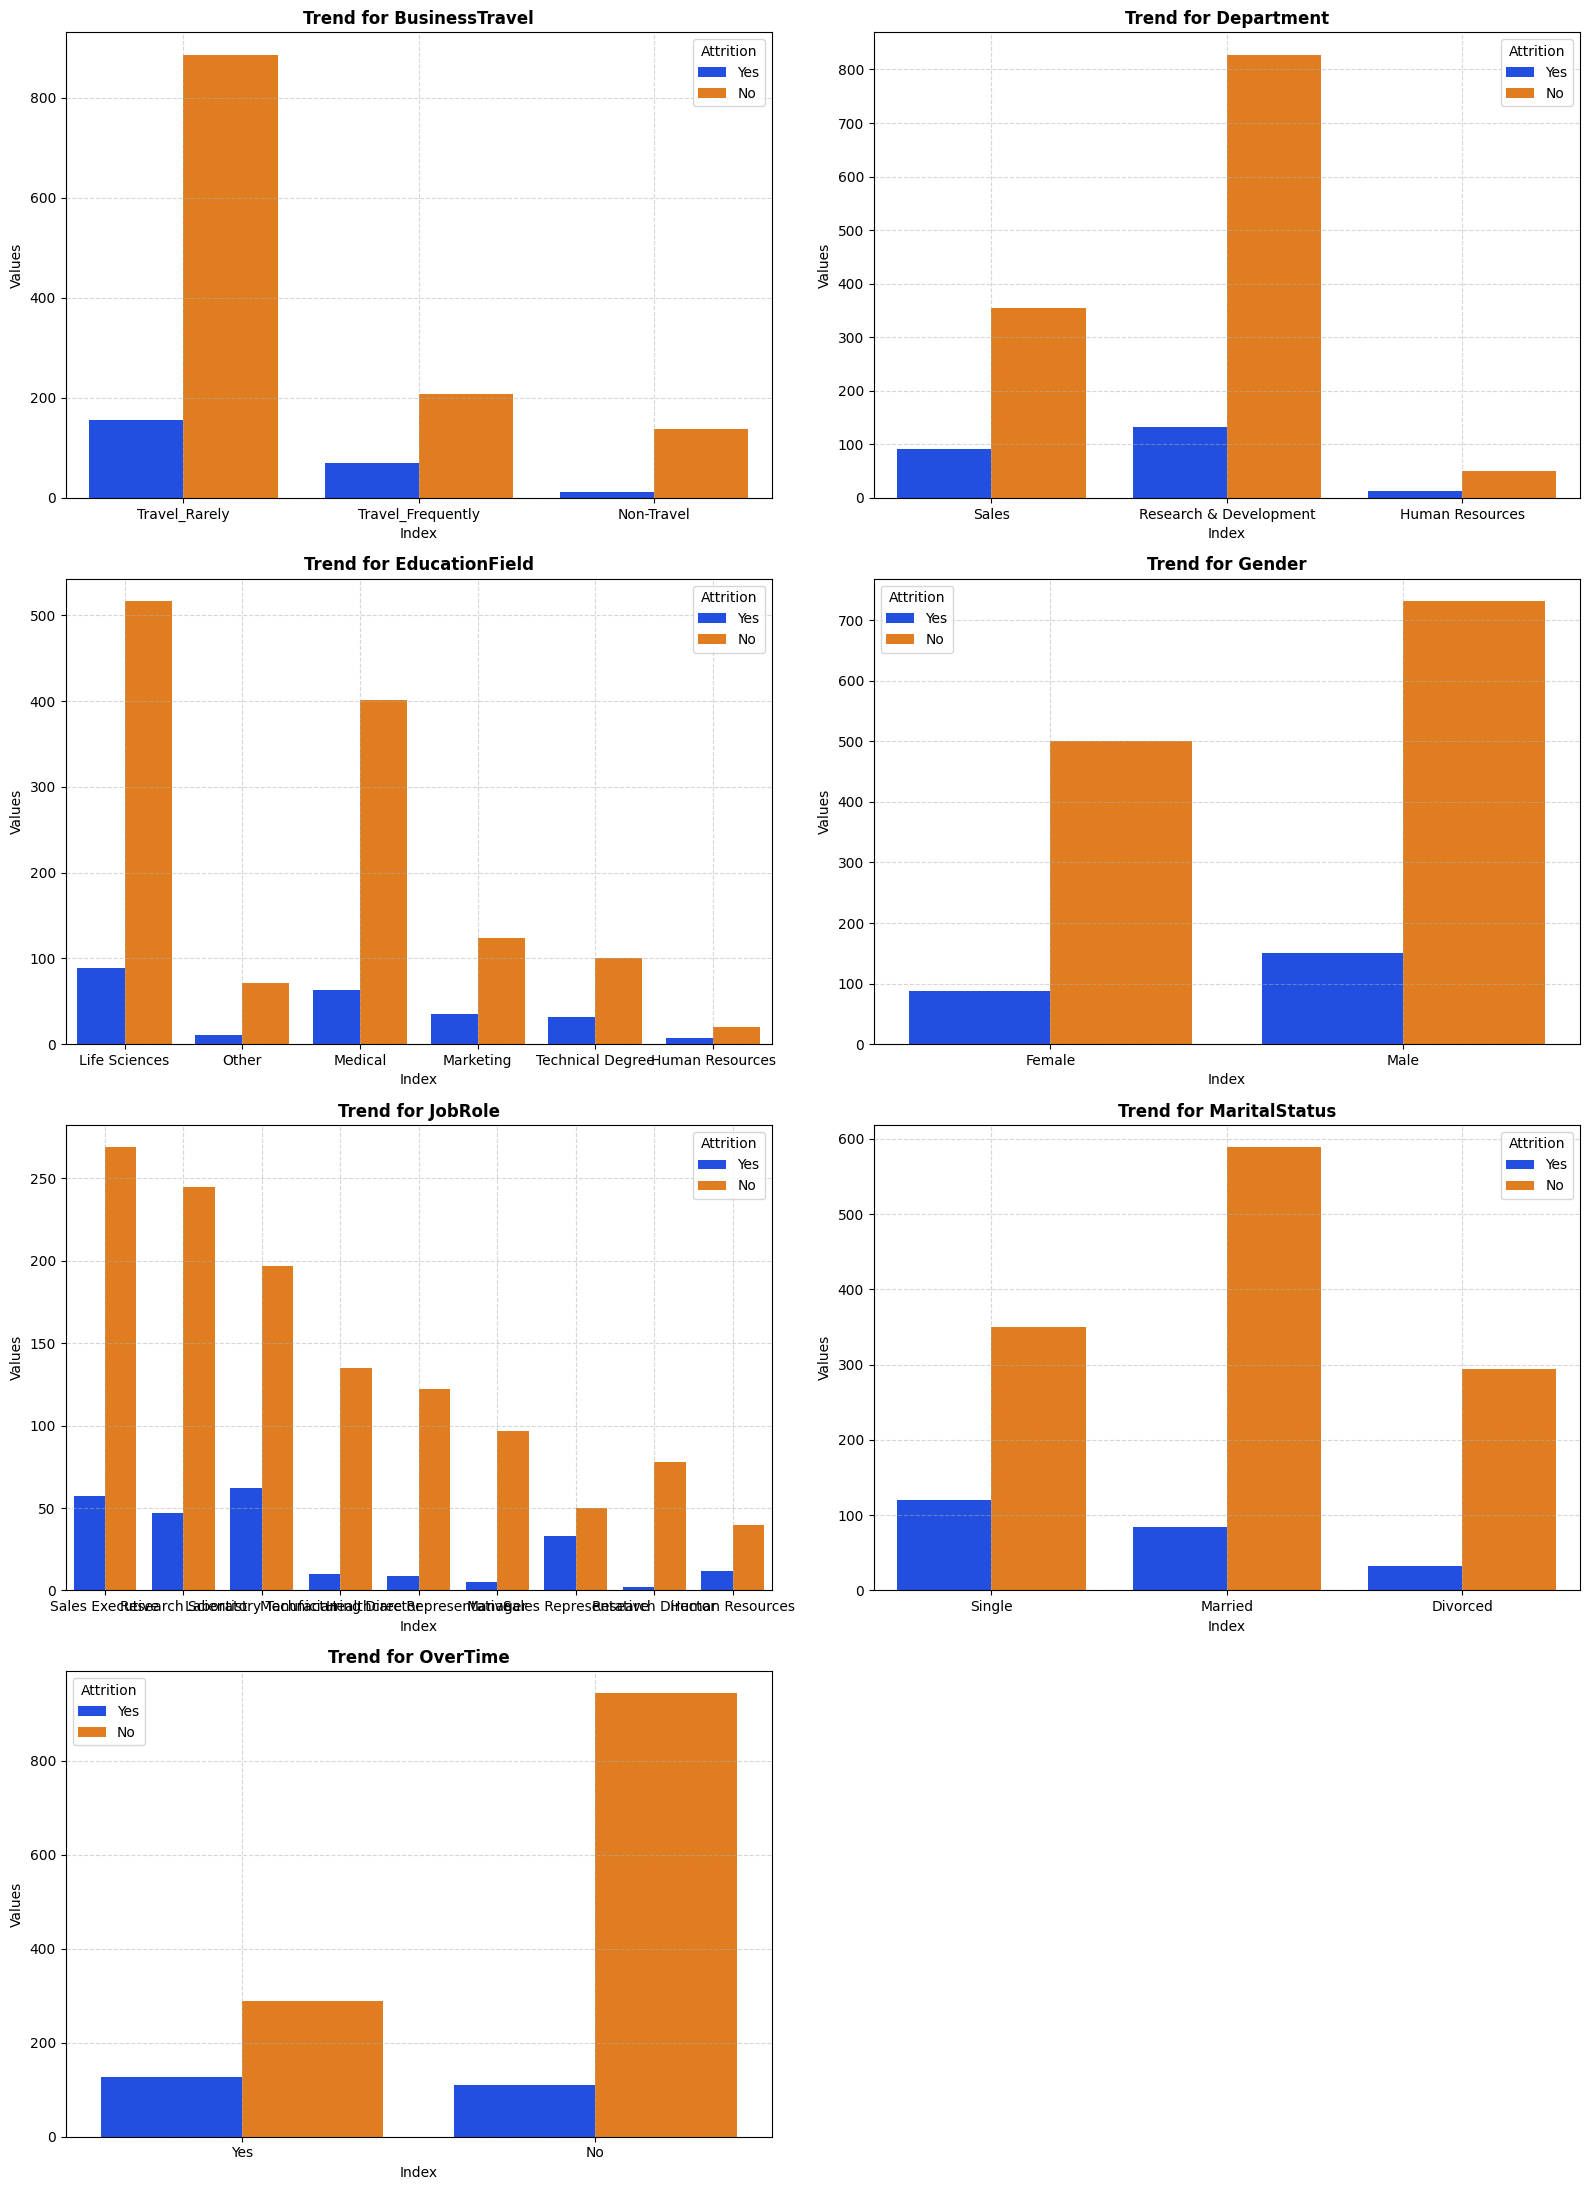

In [ ]:
#  Initialize the grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))

# Flatten the axes array for easy 1D iteration
axes_flat = axes.flatten()

#  Loop through columns and axes simultaneously
for index, col_name in enumerate(cat_cols_without_attr):
    ax = axes_flat[index]
    
    # Generate the plot on the specific axis
    sns.countplot(data=employee_df,x=col_name,hue="Attrition",palette="bright", ax=ax)
    
    # Customize the individual subplot
    ax.set_title(f'Trend for {col_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Index', fontsize=10)
    ax.set_ylabel('Values', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide any unused/empty subplots in the grid
for remaining_index in range(len(cat_cols_without_attr), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_index])

#  Optimize spacing and display
plt.tight_layout()
plt.show()

## Insights from Categorical Features

- Employees who travel frequently have a significantly higher proportion of attrition compared to those who travel rarely or not at all.
- The Sales department experiences a higher percentage rate of attrition relative to its size than Research & Development.
- Technical Degree and Marketing graduates show the highest relative rates of leaving the company.
- The proportion of employees leaving vs. staying remains relatively similar and balanced between Male and Female workers.
- Sales Representatives and Laboratory Technicians suffer from the highest proportional attrition risks among all roles.'
- Single employees are vastly more likely to leave the company compared to married or divorced individuals.
- Working Overtime is a massive driver of turnover, showing a nearly 1:2 ratio of employees leaving vs. staying.

## Checking unique values in each Categorical column

In [16]:
for col in categorical_cols:
  print("\n",col,"->",employee_df[col].unique())


 Attrition -> <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

 BusinessTravel -> <ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

 Department -> <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

 EducationField -> <ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

 Gender -> <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

 JobRole -> <ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

 MaritalStatus -> <ArrowStringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

 OverTime -> <ArrowStringArray>
['

In [67]:
yesNoMap = {"Yes":1,"No":0}
employee_df['AttritionMapped'] = employee_df['Attrition'].map(yesNoMap)
employee_df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionMapped
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1


In [68]:
corr_matrix = employee_df.corr(numeric_only=True)

## Correlation Analysis

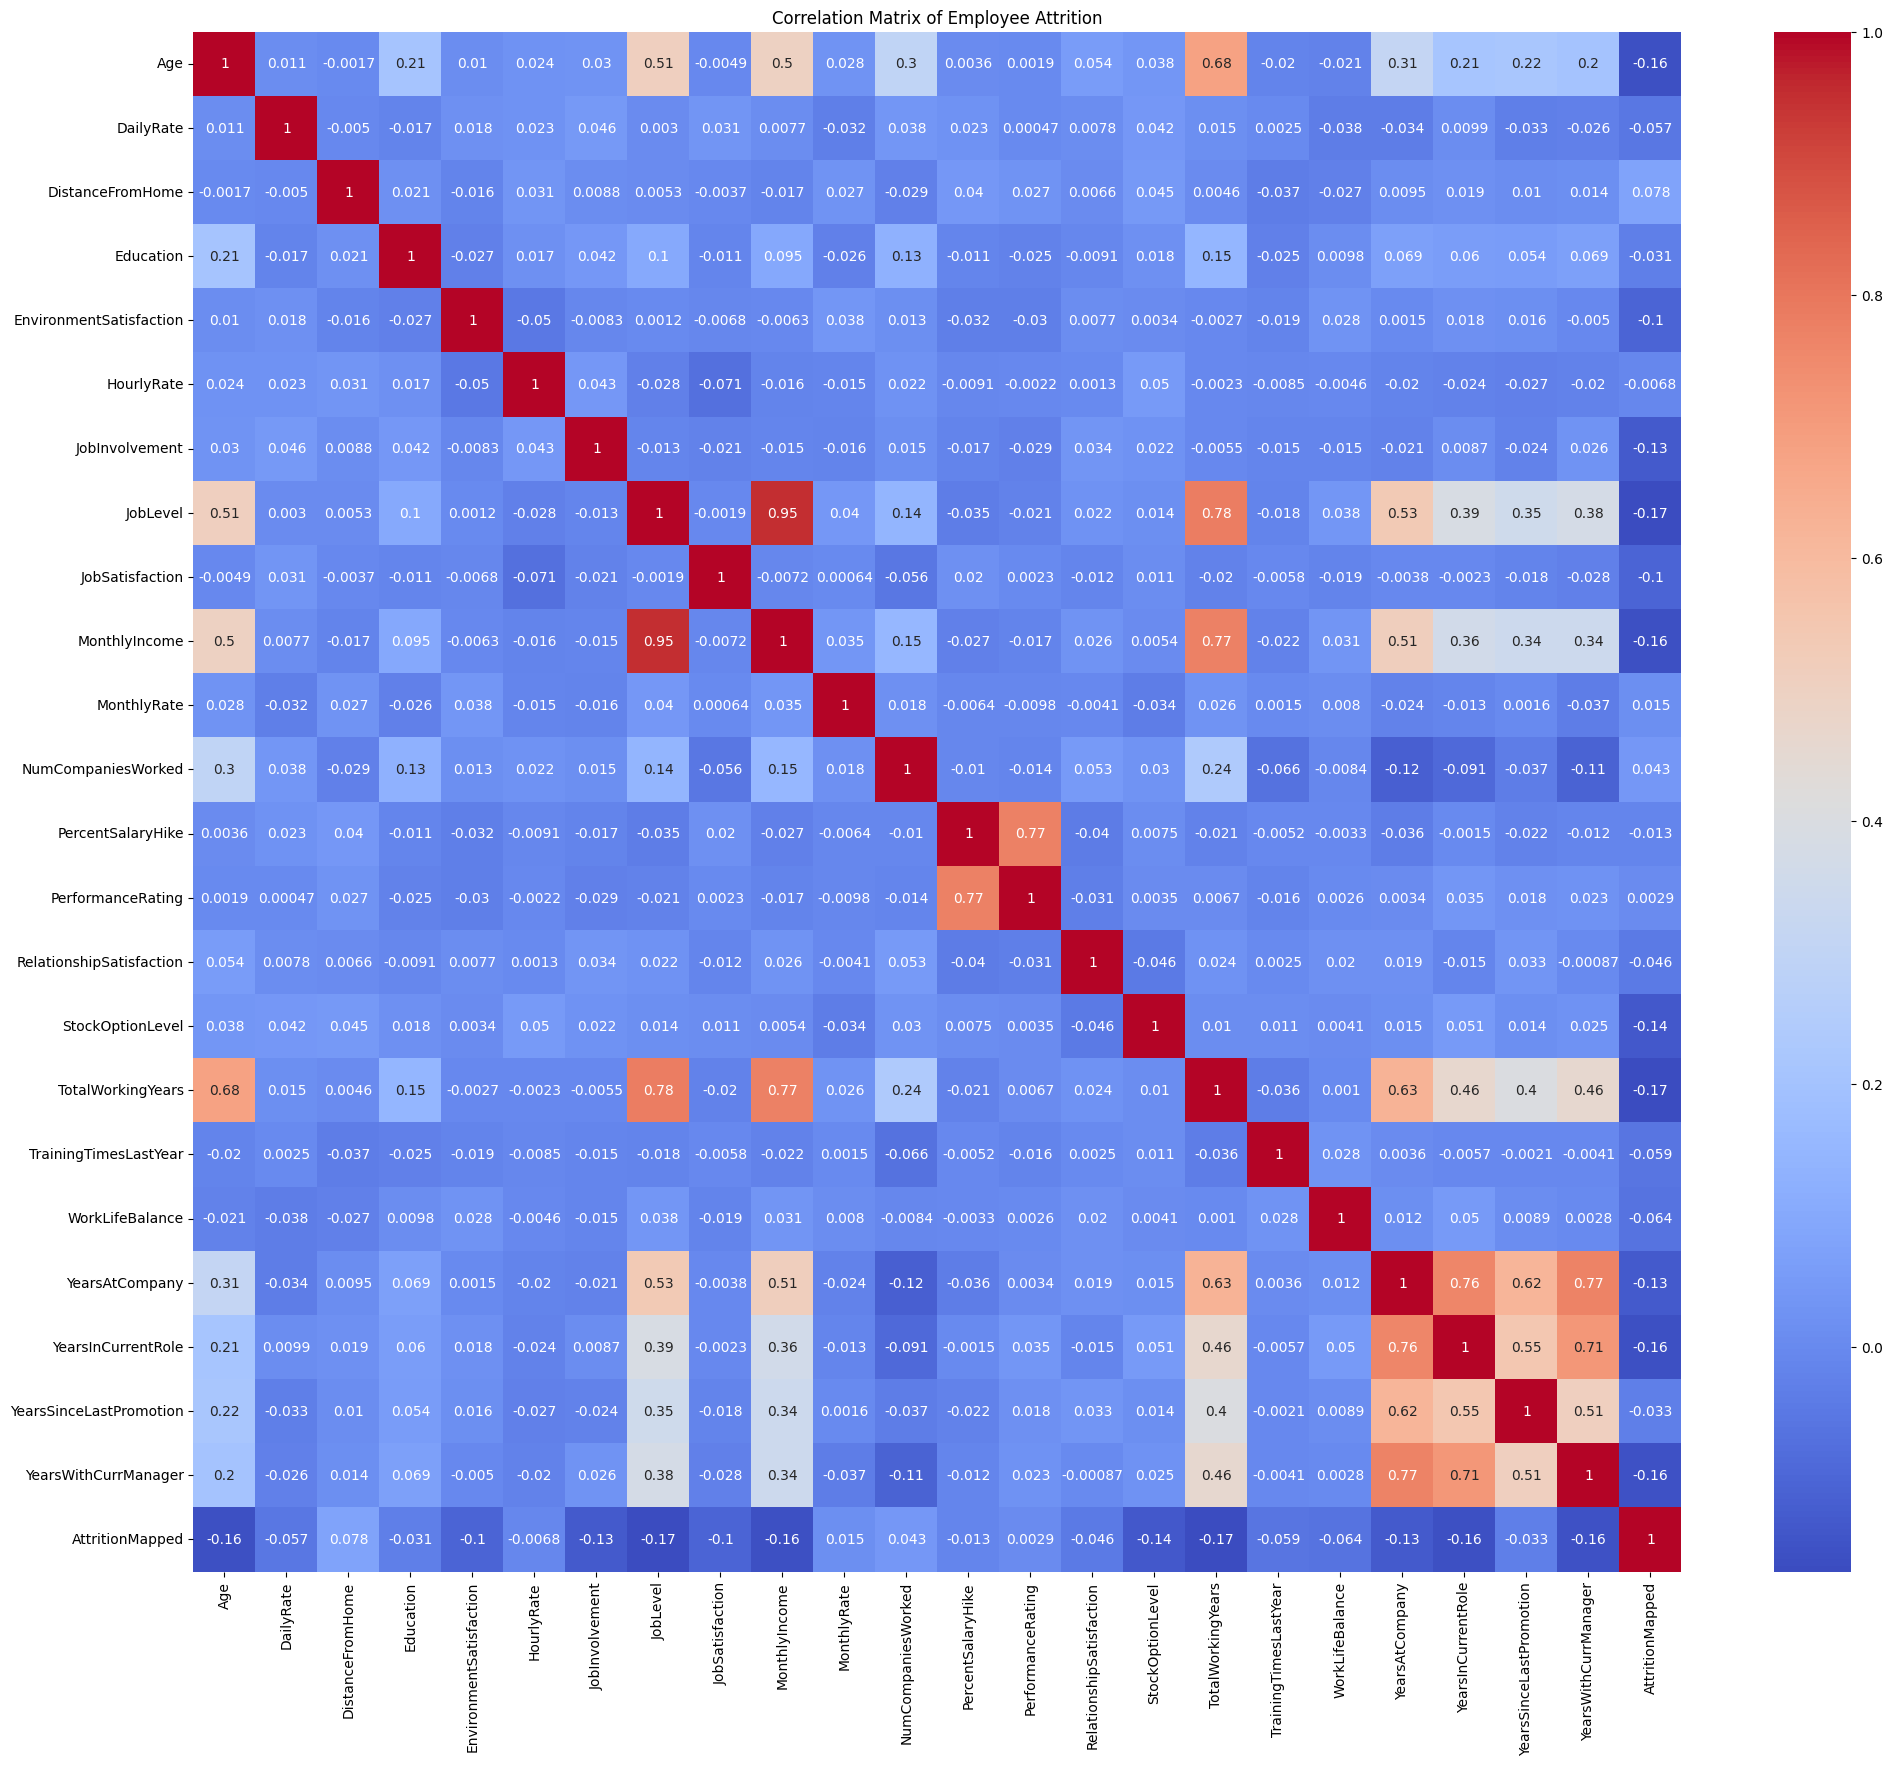

In [69]:
plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix,cmap="coolwarm",annot=True)
plt.title("Correlation Matrix of Employee Attrition")
plt.show()

In [77]:
print("Top 12 Features that impact Attrition")
print(corr_matrix['AttritionMapped'].sort_values(ascending=True)[:13])

Top 12 Features that impact Attrition
TotalWorkingYears         -0.171063
JobLevel                  -0.169105
YearsInCurrentRole        -0.160545
MonthlyIncome             -0.159840
Age                       -0.159205
YearsWithCurrManager      -0.156199
StockOptionLevel          -0.137145
YearsAtCompany            -0.134392
JobInvolvement            -0.130016
JobSatisfaction           -0.103481
EnvironmentSatisfaction   -0.103369
WorkLifeBalance           -0.063939
TrainingTimesLastYear     -0.059478
Name: AttritionMapped, dtype: float64


In [78]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [79]:
# Numerical pipeline
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical pipeline
cat_pipeline = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, cat_cols_without_attr)
])

In [80]:
# Logistic Regression
model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression())
])

In [81]:
y=employee_df['Attrition']
employee_df.drop(['Attrition','AttritionMapped'],axis=1,inplace=True)
x=employee_df
print(x.shape)
print(y.shape)

(1470, 30)
(1470,)


### Splitting the data into train and test

In [82]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [83]:
model_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [84]:
x_preds = model_pipeline.predict(x_train)
print("Classification Report on Training Data")
print(classification_report(y_train, x_preds))

Classification Report on Training Data
              precision    recall  f1-score   support

          No       0.91      0.98      0.94       978
         Yes       0.82      0.55      0.66       198

    accuracy                           0.90      1176
   macro avg       0.87      0.76      0.80      1176
weighted avg       0.90      0.90      0.90      1176



In [85]:
y_preds = model_pipeline.predict(x_test)
print("Classification Report on Test Data:")
print(classification_report(y_test, y_preds))

Classification Report on Test Data:
              precision    recall  f1-score   support

          No       0.90      0.95      0.93       255
         Yes       0.52      0.33      0.41        39

    accuracy                           0.87       294
   macro avg       0.71      0.64      0.67       294
weighted avg       0.85      0.87      0.86       294



## Random Forest Classifier Model using SMOTE to handle imbalanced Dataset

In [87]:
rfmodel_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE()),
    ('model', RandomForestClassifier(
        class_weight='balanced',n_estimators=1000,random_state=42))
])

In [89]:
# Fit the data
rfmodel_pipeline.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [90]:
xpreds_rf = rfmodel_pipeline.predict(x_train)
print("Classification Report from Random Forest - Training Report:")
print(classification_report(y_train, xpreds_rf))

Classification Report from Random Forest - Training Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       978
         Yes       1.00      1.00      1.00       198

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [91]:
y_preds = rfmodel_pipeline.predict(x_test)
print("Classification Report from Random Forest - Test Report [Default Threshold - 0.5]")
print(classification_report(y_test, y_preds))

Classification Report from Random Forest - Test Report [Default Threshold - 0.5]
              precision    recall  f1-score   support

          No       0.89      0.96      0.92       255
         Yes       0.47      0.23      0.31        39

    accuracy                           0.86       294
   macro avg       0.68      0.60      0.62       294
weighted avg       0.84      0.86      0.84       294



### Checking the Classification Report for different Thresholds - 0.2,0.3,0.4,0.5(Default)

In [93]:
print("Random Forest - Report:")
y_probas = rfmodel_pipeline.predict_proba(x_test)[:, 1]
prob_threshold = [0.2,0.3,0.4,0.5]
for i in prob_threshold:
    y_pred_news = (y_probas > i).astype(int)
    y_pred_news = np.where(y_pred_news == 1, 'Yes', 'No')
    print(f"********************Random Forest - Report for Threshold -{i}*******************")
    print(classification_report(y_test, y_pred_news))

Random Forest - Report:
********************Random Forest - Report for Threshold -0.2*******************
              precision    recall  f1-score   support

          No       0.94      0.66      0.78       255
         Yes       0.25      0.74      0.37        39

    accuracy                           0.67       294
   macro avg       0.60      0.70      0.58       294
weighted avg       0.85      0.67      0.72       294

********************Random Forest - Report for Threshold -0.3*******************
              precision    recall  f1-score   support

          No       0.91      0.84      0.88       255
         Yes       0.32      0.49      0.38        39

    accuracy                           0.79       294
   macro avg       0.62      0.66      0.63       294
weighted avg       0.84      0.79      0.81       294

********************Random Forest - Report for Threshold -0.4*******************
              precision    recall  f1-score   support

          No       0.90 

### Listing out important Features

In [97]:
feature_names = rfmodel_pipeline.named_steps['preprocessing'].get_feature_names_out()
rf_model = rfmodel_pipeline.named_steps['model']
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(20))

                                  feature  importance
49                       cat__OverTime_No    0.079558
50                      cat__OverTime_Yes    0.078308
7                           num__JobLevel    0.047555
15                  num__StockOptionLevel    0.044319
16                 num__TotalWorkingYears    0.037292
0                                num__Age    0.036557
19                    num__YearsAtCompany    0.035858
48              cat__MaritalStatus_Single    0.035453
9                      num__MonthlyIncome    0.035018
22              num__YearsWithCurrManager    0.027628
8                    num__JobSatisfaction    0.027424
20                num__YearsInCurrentRole    0.026350
4            num__EnvironmentSatisfaction    0.026195
6                     num__JobInvolvement    0.024758
5                         num__HourlyRate    0.022803
24  cat__BusinessTravel_Travel_Frequently    0.022436
1                          num__DailyRate    0.022107
2                   num__Dis

# Overall Insights & Key Findings

The exploratory data analysis revealed several important characteristics of the employee attrition dataset.

- The dataset is moderately imbalanced, with employees who stay significantly outnumbering those who leave. This motivated the use of SMOTE during model training.

- Monthly Income, Job Level, Total Working Years, and Years at Company exhibit positive relationships, indicating that employee experience generally increases with compensation and seniority.

- Employees working overtime show a noticeably higher likelihood of attrition compared to employees who do not work overtime.

- Employees with fewer years at the company and fewer years in their current role appear more likely to leave the organization.

- Variables such as EmployeeCount and Over18 contain little or no predictive information and were removed during preprocessing.

- Several numerical variables contain outliers. Since the selected Random Forest model is tree-based and relatively robust to outliers, no explicit outlier treatment was performed.

- Correlation analysis indicates moderate relationships among experience-related features but no severe multicollinearity that would significantly impact the selected model.

- The Random Forest model identified features such as Monthly Income, OverTime, Total Working Years, Age, Job Level, Years at Company, and Environment Satisfaction as among the most influential predictors of employee attrition.